# Calculate Equilibrium

The equilibrium is obtained by guessing the equilibrium structure and then calculating the optimal policies given this structure. Eventually it is checked whether the initially guessed structure did indeed result.

In detail: 
- Two threshold values for $\alpha$ are guessed: below the lower one DM is assumed to exit for sure and between the two thresholds DM is assumed to continue for sure; above the higher threshold A is assumed to have value Vfinal which is obtained in the proof of proposition 2; above the higher threshold and below the lower thereshold DM's value function is assumed to equal his outside option. 
- A's optimal policy -- given this structure -- the two thresholds is determined. 
- Given A's optimal policy, DM's optimal policy and value function is obtained for $\alpha$ between the thresholds.
- It is checked whether the resulting policies/value functions consitute an equilibrium that is in line with the initially assumed structure.

The "search_for_eq" function can be used to search for thresholds that lead to an equilibrium of the above form.

The code below is written in [Julia](www.julialang.org).

In [2]:
using PyPlot
using Distributions
using Interpolations

#discount rate delta
const d = 0.95
#vector of posterior probabilities  ordered from highest to lowest
const p = (0.9,0.08,0.02) #yields an eq with al=.54, ab=.56; with W0 = 6.85 and d= 0.95
#number of options
const n = length(p)
#value of outside option
const W0 = 6.75 #1.0/(n*(1-d))+0.2 #6.85

#calculate the probability of fitting advice for all possible cutoff strategies and save them in the vector phit
function construct_phit()
    phit = Array(Float64,length(p))
    for j in 1:length(p)
        phit[j] = sum(p[1:j])/n+(n-j)*p[1]/n
    end
    return phit
end
const phit = construct_phit()

# calculates the highest cutoff for which the consumer prefers getting advise at this cutoff forever to taking the outside option;
const kt = sum(phit.>W0*(1-d))

#value in region where E mixes over kt and kt+1
const Vfinal = ((kt+1)/n-(1.0-phit[kt+1])/(p[1]-p[kt+1]))/(1.0-d)

#generates a V function/interpolation object zero below "low", Vfinal above high and linear and continuous in between
function Vstart(low::Float64,high::Float64)
    knots = [0.0, low,high,1.0]
    return interpolate((knots,),[0.0,0.0,Vfinal,Vfinal],Gridded(Linear()))
end

#alpha plus, i.e. updated belief after a hit with pure cutoff
function ap(alpha::Float64,cutoff::Int64)
    return alpha*phit[cutoff]/((1-alpha)/n+alpha*phit[cutoff])
end

#alpha minus, i.e updated belief after a miss with pure cutoff
function am(alpha::Float64,cutoff::Int64)
    return alpha*(1-phit[cutoff])/((1-alpha)*(n-1)/n+alpha*(1-phit[cutoff]))
end

#gives optimal cutoff at "point" given value function V
function opt_cutoff(V::Interpolations.GriddedInterpolation,point::Float64,low::Float64,high::Float64)
        if point<=low
            return n
        elseif point>high 
            return kt
        else
            cutoff = 1
            aplus = ap(point,cutoff)
            amin = am(point,cutoff)
            if p[1]-p[2]<1.0/(d*(V[aplus]-V[amin]))#then 1 is not optimal cutoff
                cutoff = 2
                aplus = ap(point,cutoff)
                amin = am(point,cutoff)
                while p[1]-p[cutoff]<1.0/(d*(V[aplus]-V[amin]))
                    cutoff = cutoff + 1
                    aplus = ap(point,cutoff)
                    amin = am(point,cutoff)
                    if cutoff == n
                        break 
                    end
                end
            end
            return cutoff
        end
    end

#returns Vtilde (and optimal cutoffs) given V and low/high value to/from which V is constant
function Vtilde(V::Interpolations.GriddedInterpolation,low::Float64,high::Float64,step::Float64=0.001)
    knots = [0.0;low;[j for j in low:step:high];high+0.00001;1.0] #grid on which V is evaluated (outside grid: linear interpolation)
    Vtilde_on_knots = Array(Float64,length(knots))
    cutoff_on_knots = Array(Int64,length(knots))
    for (i,a) in enumerate(knots)
        if a<=low
            Vtilde_on_knots[i] = 0.0
            cutoff_on_knots[i] = n
        elseif a>high 
            Vtilde_on_knots[i] = Vfinal
            cutoff_on_knots[i] = kt
        else   
            cutoff = opt_cutoff(V,a,low,high)
            aplus = ap(a,cutoff)
            amin = am(a,cutoff)
            Vtilde_on_knots[i] = phit[cutoff]*d*V[aplus]+(1-phit[cutoff])*d*V[amin]+cutoff/n
            cutoff_on_knots[i] = cutoff
        end
    end
    return interpolate((knots,),Vtilde_on_knots,Gridded(Linear())),interpolate((knots,),cutoff_on_knots,Gridded(Linear()))
end

#for given exit thresholds low and high, computes a V such that optimality condition is satisfied everywhere between low and high
function Vcand(low::Float64, high::Float64,step::Float64=0.001,Vtol::Float64=0.001)
    diffV = 1.0
    out = Vstart(low,high)
    helper = Tuple{Interpolations.GriddedInterpolation,Interpolations.GriddedInterpolation}
    k = 1
    while diffV>min(Vtol,Vfinal/100) && k<1000
        helper = Vtilde(out,low,high,step)
        #diffV = maximum([abs(helper[1][a]-out[a]) for a in low:step:high])
        diffV = sum([abs(helper[1][a]-out[a]) for a in low:step:high])
        out = helper[1]
        k = k + 1
    end
    return out,helper[2]#returns the V function/interpolation object as well as optimal cutoffs for V 
end

#value function iteration for decision maker (note this Wtilde is a contraction, hence convergence is unproblematic)
function Wtilde(W::Interpolations.GriddedInterpolation,cutoffs::Interpolations.GriddedInterpolation,low::Float64,high::Float64)
    knots = [0.0;low;[j for j in low:0.001:high];high+0.00001;1.0] #grid on which W is evaluated (outside grid: linear interpolation)
    Wtilde_on_knots = Array(Float64,length(knots))
    for (i,a) in enumerate(knots)
        if a<=low || a>high 
            Wtilde_on_knots[i] = W0
        else
            prob = phit[Int(cutoffs[a])]*a+(1-a)/n#prob of good advice
            aplus = ap(a,Int(cutoffs[a]))
            amin = am(a,Int(cutoffs[a]))
            Wtilde_on_knots[i] = prob*(d*W[aplus]+1)+(1-prob)*d*W[amin]
        end
    end
    return interpolate((knots,),Wtilde_on_knots,Gridded(Linear()))
end

function Wstart(low::Float64,high::Float64)
    knots = [0.0, low,(low+high)/2,high,1.0]
    return interpolate((knots,),[W0,W0,1.5*W0,W0,W0],Gridded(Linear()))
end

function Wcand(cutoffs::Interpolations.GriddedInterpolation,low::Float64,high::Float64)
    out = Wstart(low,high)
    diffW = 1.0
    while diffW>min(0.001,W0/100)
        helper = Wtilde(out,cutoffs,low,high)
        diffW = sum([abs(helper[a]-out[a]) for a in low+0.001:0.001:high-0.001])
        out = helper
    end
    return out
end

#checks whether a given low and high form an eq (sufficient not necessary, i.e. some flagged low/highs might nevertheless be eq)
function check_eq(low::Float64,high::Float64,quiet::Bool=false,step::Float64=0.001,Vtol::Float64=0.001)
    V,cutoffs = Vcand(low,high,step,Vtol)
    W = Wcand(cutoffs,low,high)
    flag = 0
    #returns difference between W(alpha) and W0 if E mixes between kt and kt+1 with probability q (for values of alpha above high only)
    function diff_W0_Wamin(alpha::Float64,q::Float64)
        prob = q*phit[kt]+(1-q)*phit[kt+1]#prob that knowledgeable E has hit
        amin = (1-prob)/((1-alpha)*(n-1)/(alpha*n)+(1-prob))
        return (alpha*prob+(1-alpha)/n)*(1+d*W0)+(1-alpha*prob-(1-alpha)/n)*d*W[amin]-W0
    end
    for alpha in high+0.005:0.005:0.999
        subflag = 1
        for q in 0.0:0.005:1.0
            if -0.005<=diff_W0_Wamin(alpha,q)<=0.005#true if mixing with q will lead to W(alpha)=W0
                subflag = 0
                break
            end
        end
        if subflag == 1
            if quiet == false
                println("E cannot mix C down to W0 at", alpha)
            end
            flag = 1
        end
    end
    if minimum([V[a]-V[a-step] for a in low+step:step:high])<-min(Vtol,0.0001)
        if quiet == false
            println("V possibly not monotone")
        end
        flag = 1
    end
    if minimum(W[low:0.001:high])<W0-0.001 
        if quiet == false
            println("W below outside option for some belief")
        end
        flag = 1
    end
    beta_high = (Vfinal-1.0/(d*p[1]-d*p[kt+1]))/Vfinal
    if beta_high>1 || beta_high<0
        if quiet == false
            println("C cannot mix E to Vfinal")
        end
        flag = 1
    end
    if flag==0
        if quiet == false
            println("equilibrium")
        end
        return true,V,W,cutoffs
    else
        return false,V,W,cutoffs
    end
end

#searches for thresholds where the algorithm can detect equilibria (not used below)
function search_for_eq(lowest::Float64=0.1,highest::Float64=0.9,step::Float64=0.01,all::Bool=false,innerstep::Float64=0.001,Vtol::Float64=0.001)
    all_results = Any[]
    for low in lowest:step:highest-step
        for high in low+0.05:step:highest
            result = check_eq(low,high,true,innerstep,Vtol)
            if result[1] == true
                if all == false
                    println("equilibrium with lower and upper threshold",low," ",high)
                    return result
                else
                    append!(all_results,[low,high,result])
                end
            end
        end
    end
    return all_results
end


search_for_eq (generic function with 7 methods)

# Create figures

equilibrium


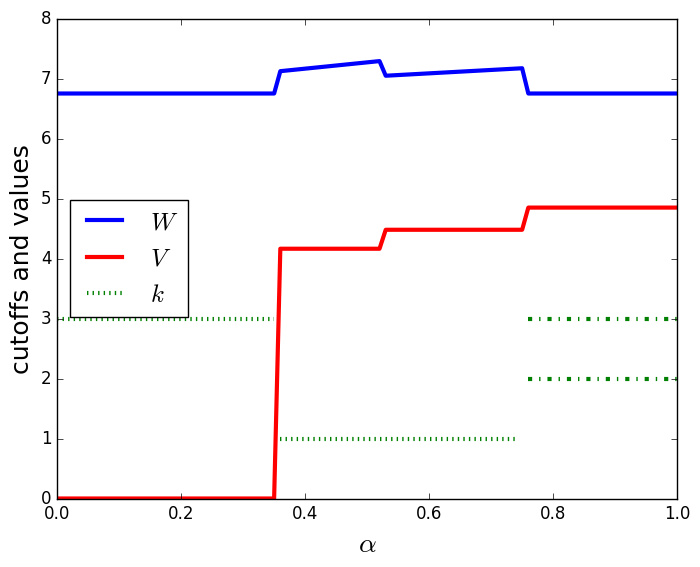

In [3]:
##VW figure
lows = 0.35 #low threshold in equilibrium
highs = 0.75 # high threshold in equilibrium

sol = check_eq(lows,highs,false,0.001,0.001)

fig, ax = subplots()
ax[:set_xlabel](L"$\alpha$",fontsize=20)
ax[:set_ylabel]("cutoffs and values",fontsize=18)

ax[:plot](0:0.01:1,sol[3][0:0.01:1],"b",linewidth = 3, label=L"$W$")
ax[:plot](0:0.01:1,sol[2][0:0.01:1],"r",linewidth = 3,label=L"$V$")
ax[:plot](0:0.01:lows,sol[4][0:0.01:lows],"g:",linewidth = 3,label=L"$k$")
ax[:plot](lows+0.01:0.01:highs-0.01,sol[4][lows+0.01:0.01:highs-0.01],"g:",linewidth = 3)
ax[:plot](highs+0.01:0.01:1.0,sol[4][highs+0.01:0.01:1.0],"g-.",linewidth = 3)
ax[:plot](highs+0.01:0.01:1.0,sol[4][highs+0.01:0.01:1.0].+1.0,"g-.",linewidth = 3)
ax[:legend](loc="center left",fontsize=18)

savefig("VW.pdf",bbox_inches="tight")
savefig("VW.png",bbox_inches="tight")


# Simulations

In [4]:
using Roots

##create the mixing equilibrium  probabilities for alpha above "highs"
function eq_mix(low::Float64,high::Float64,V::Interpolations.GriddedInterpolation,W::Interpolations.GriddedInterpolation,cutoffs::Interpolations.GriddedInterpolation)
    #returns difference between W(alpha) and W0 if E mixes between kt and kt+1 with probability q (for values of alpha above high only)
    function diff_W0_Wamin(alpha::Float64,q::Float64)
        prob = q*phit[kt]+(1-q)*phit[kt+1]#prob that knowledgeable E has hit
        amin = (1-prob)/((1-alpha)*(n-1)/(alpha*n)+(1-prob))
        return (alpha*prob+(1-alpha)/n)*(1+d*W0)+(1-alpha*prob-(1-alpha)/n)*d*W[amin]-W0
    end
    knots = [0.0;low-0.000001;low;high;[i for i in high+0.00001:0.005:0.999]]
    mixA_on_knots = Array(Float64,length(knots)) #mixing of adviser
    mixDM_on_knots = Array(Float64,length(knots)) #mixing of decision maker if recommendation is bad
    for (i,a) in enumerate(knots)
        if i <2.5 #alpha below lows
            mixA_on_knots[i] = 0.0
            mixDM_on_knots[i] = 0.0
            elseif i <4.5 #alpha between lows and highs
            mixA_on_knots[i] = 1.0
            mixDM_on_knots[i] = 1.0
            else #alpha above highs
            f(x) = diff_W0_Wamin(a,x)
            q = fzero(f,[0.0,1.0])
            mixA_on_knots[i] = q
            prob = q*phit[kt]+(1-q)*phit[kt+1]#prob that knowledgeable E gives right recommendation
            amin = (1-prob)/((1-a)*(n-1)/(a*n)+(1-prob))
            aplus = prob/((1-a)/(a*n)+prob)
            mixDM_on_knots[i] = (V[aplus]-1./(d*p[1]-d*p[kt+1]))/(V[amin])
        end
    end
    mixA = interpolate((knots,),mixA_on_knots,Gridded(Linear()))# mixing of the adviser 
    mixDM = interpolate((knots,),mixDM_on_knots,Gridded(Linear()))# mixing of DM if recommendation was bad
    return mixA, mixDM #returns interpolation object
end

mix = eq_mix(lows,highs,sol[2],sol[3],sol[4]);



In [5]:
#setting random seed
srand(123)

#T will contain mean length of relationship at each alpha 0.0:0.01:1
T = Array(Float64,length(lows+0.01:0.01:0.99))
# all_t will contain simulated lengths of all draws and can be used to generate histograms
all_t = Array(Int64,100000,length(lows+0.01:0.01:0.99))

#actual simulation
for (i,al_start) in enumerate(lows+0.01:0.01:0.99) #starting alpha in steps of 0.01
    for draw in 1:100000 #100000 draws per starting alpha
        flag = 0 #0 indicates that relationship still active, flag=1 means that DM exits
        al = al_start
        t = 1 #counter for periods, i.e. number of times DM asks for advice before exiting
        while flag==0
            q = mix[1][al] #probability with which A uses cutoff[al], with counterprobability kt+1 is used
            prob = q*phit[convert(Int64,round(sol[4][al]))]+(1-q)*phit[kt+1]#prob that knowledgeable E has hit
            if rand()<prob #if true, then good recommendation
                al = prob/((1-al)/(al*n)+prob) #alpha^+
                if al<=lows
                    flag = 1
                else
                    t = t+1
                end
                else #i.e. bad recommendation
                al = (1-prob)/((1-al)*(n-1)/(al*n)+(1-prob)) # alpha^-
                if al<=lows
                    flag = 1
                elseif al<highs
                    t = t + 1
                else
                    if mix[2][al]>rand() #if true then DM stops game after bad recommendation and al>highs
                        t = t+1
                    else
                        flag = 1
                    end
                end
            end
        end
        all_t[draw,i] = t
    end
    T[i]=mean(all_t[1:end,i])
end

## Figures given that adviser is of high quality

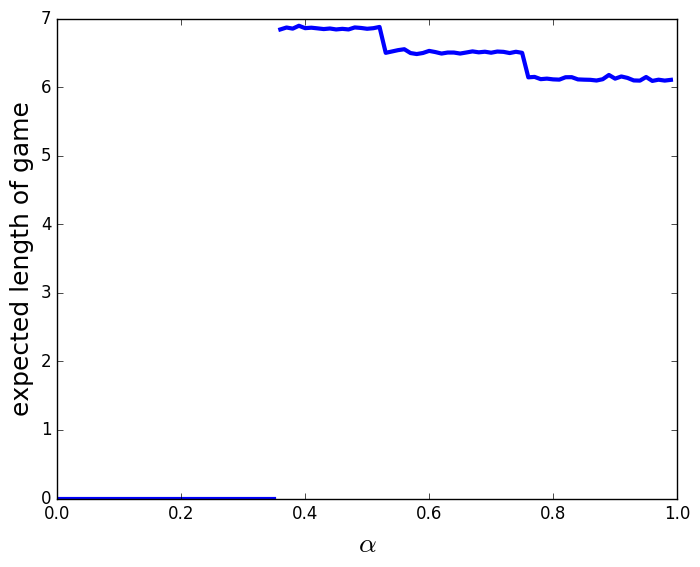

In [6]:
##Figure average length of game
fig, ax = subplots()
ax[:set_xlabel](L"$\alpha$",fontsize=20)
ax[:set_ylabel]("expected length of game",fontsize=18)
ax[:plot]([0.0,lows],[0.0,0.0],"b",linewidth = 3)
ax[:plot]([i*(0.99-lows)/length(T)+lows for i in 1:length(T)],T,"b",linewidth = 3)
savefig("expT.png")
savefig("expT.pdf")

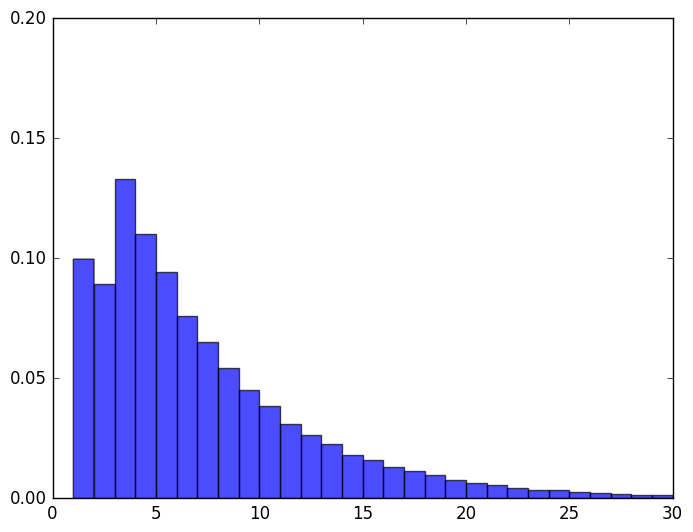

In [8]:
##Histogram for alpha=0.4
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.2)
ax[:hist](all_t[1:end,Int(40-round(100*lows))],bins=70,alpha=0.7,normed=true)
savefig("histogram40.png")
savefig("histogram40.pdf")

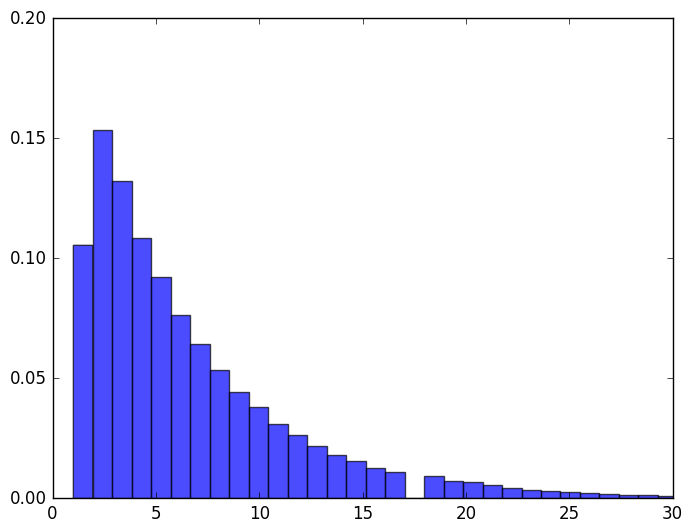

In [22]:
##Histogram for alpha=0.6
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.2)
ax[:hist](all_t[1:end,Int(60-round(100*lows))],bins=70,alpha=0.7,normed=true)
savefig("histogram60.png")
savefig("histogram60.pdf")

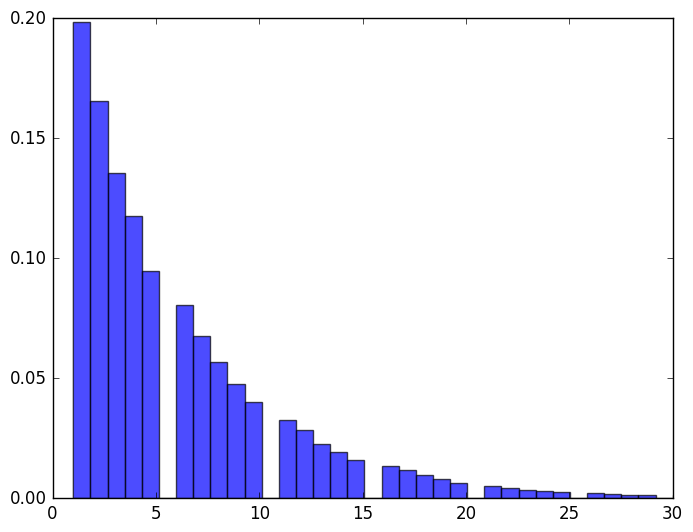

In [23]:
##Histogram for alpha=0.8
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.2)
ax[:hist](all_t[1:end,Int(80-round(100*lows))],bins=70,alpha=0.7,normed=true)
savefig("histogram80.png")
savefig("histogram80.pdf")

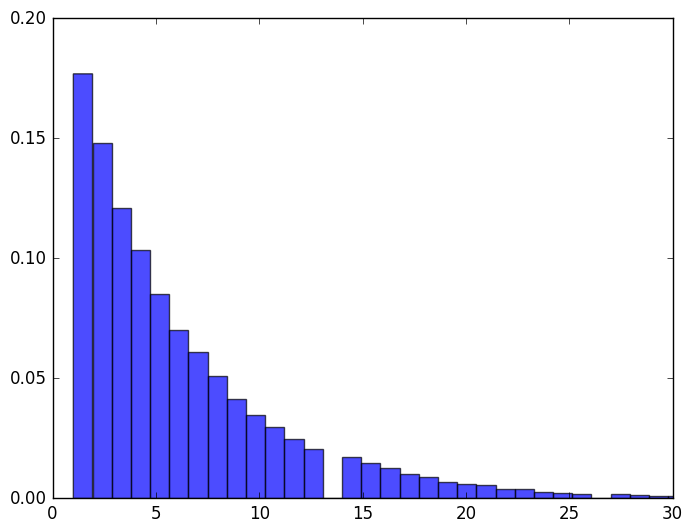

In [24]:
##Histogram for alpha=0.95
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.2)
ax[:hist](all_t[1:end,Int(95-round(100*lows))],bins=70,alpha=0.7,normed=true)
savefig("histogram95.png")
savefig("histogram95.pdf")

In [33]:
###probability to have a game length of more than 10 if alpha=0.95
mean([t>10 for t in all_t[1:end,Int(95-round(100*lows))]])

0.1705

## Figures and simulations given that DM has correct starting belief (i.e. adviser is of low quality with probability $\alpha$ and we do not condition on the event that A is competent)

In [9]:
#setting random seed
srand(123)

#T will contain mean length of relationship at each alpha 0.0:0.01:1 if adviser is of low quality
T_bad = Array(Float64,length(lows+0.01:0.01:0.99))
# all_t_bad will contain simulated lengths of all draws and can be used to generate histograms if adviser is of low quality
all_t_bad = Array(Int64,100000,length(lows+0.01:0.01:0.99))

#actual simulation
for (i,al_start) in enumerate(lows+0.01:0.01:0.99) #starting alpha in steps of 0.01
    for draw in 1:100000 #100000 draws per starting alpha
        flag = 0 #0 indicates that relationship still active, flag=1 means that DM exits
        al = al_start
        t = 1 #counter for periods, i.e. number of times DM asks for advice before exiting
        while flag==0
            q = mix[1][al] #probability with which knowledgable A uses cutoff[al], with counterprobability kt+1 is used
            prob = q*phit[convert(Int64,round(sol[4][al]))]+(1-q)*phit[kt+1]#prob that knowledgeable E has hit
            if rand()<1.0/n #if true, then good recommendation (recall: bad expert has right recommendation with probability 1/n)
                al = prob/((1-al)/(al*n)+prob) #alpha^+
                if al<=lows
                    flag = 1
                else
                    t = t+1
                end
                else #i.e. bad recommendation
                al = (1-prob)/((1-al)*(n-1)/(al*n)+(1-prob)) # alpha^-
                if al<=lows
                    flag = 1
                elseif al<highs
                    t = t + 1
                else
                    if mix[2][al]>rand() #if true then DM stops game after bad recommendation and al>highs
                        t = t+1
                    else
                        flag = 1
                    end
                end
            end
        end
        all_t_bad[draw,i] = t
    end
    T_bad[i]=mean(all_t_bad[1:end,i])
end



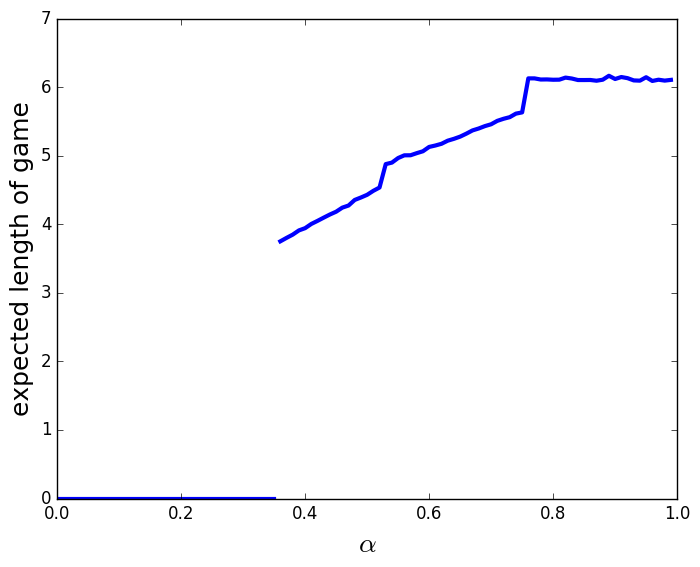

In [10]:
#T_combined contains expected length of game when starting with correct belief alpha for alpha in lows+0.01:0.01:0.99
T_combined = Array(Float64,length(lows+0.01:0.01:0.99))
for (i,a) in enumerate(lows+0.01:0.01:0.99)
    T_combined[i] = a*T[i]+(1-a)*T_bad[i]
end

##Figure average length of game
fig, ax = subplots()
ax[:set_xlabel](L"$\alpha$",fontsize=20)
ax[:set_ylabel]("expected length of game",fontsize=18)
ax[:plot]([0.0,lows],[0.0,0.0],"b",linewidth = 3)
ax[:plot]([i*(0.99-lows)/length(T_combined)+lows for i in 1:length(T_combined)],T_combined,"b",linewidth = 3)
ax[:legend](loc="lower right",fontsize=18)
savefig("expT_combi.png")
savefig("expT_combi.pdf")

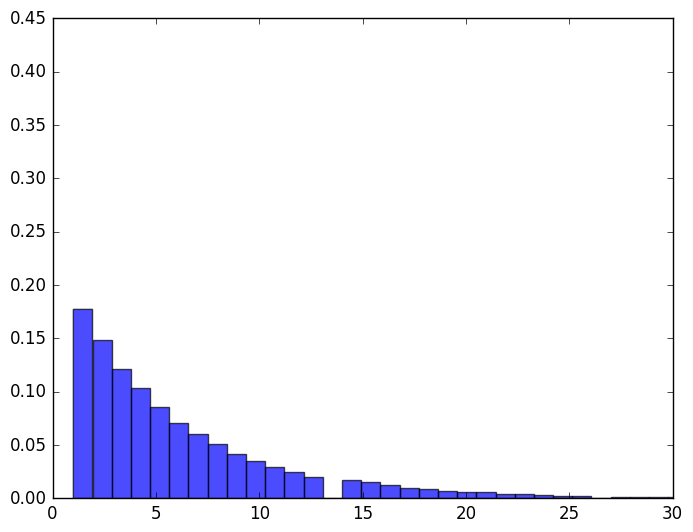

In [25]:
##Histogram for alpha=0.95
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.45)
#note the mix of all_t and all_t_bad
t95combi = vcat(all_t[1:95000,Int(95-round(100*lows))],all_t_bad[1:5000,Int(95-round(100*lows))])
ax[:hist](t95combi,bins=70,alpha=0.7,normed=true)
savefig("histogram95combi.png")
savefig("histogram95combi.pdf")

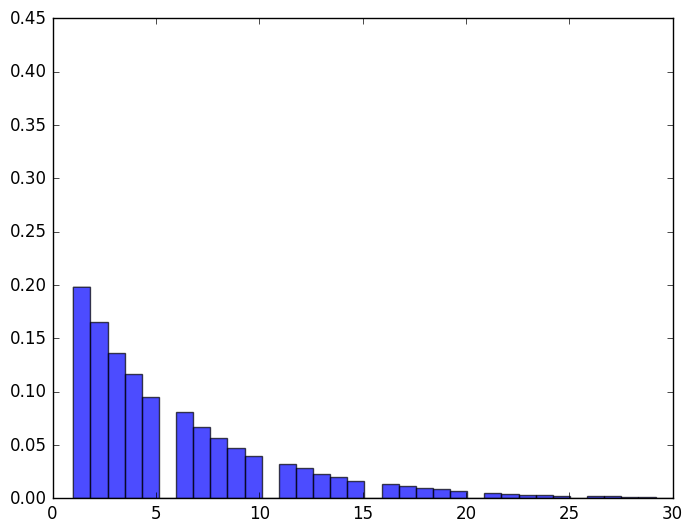

In [26]:
##Histogram for alpha=0.8
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.45)
#note the mix of all_t and all_t_bad
t80combi = vcat(all_t[1:80000,Int(80-round(100*lows))],all_t_bad[1:20000,Int(80-round(100*lows))])
ax[:hist](t80combi,bins=70,alpha=0.7,normed=true)
savefig("histogram80combi.png")
savefig("histogram80combi.pdf")

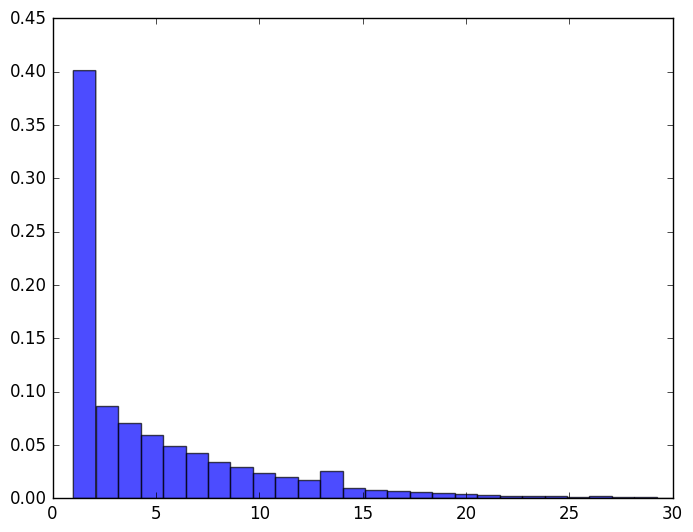

In [27]:
##Histogram for alpha=0.6
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.45)
#note the mix of all_t and all_t_bad
t60combi = vcat(all_t[1:60000,Int(60-round(100*lows))],all_t_bad[1:40000,Int(60-round(100*lows))])
ax[:hist](t60combi,bins=70,alpha=0.7,normed=true)
savefig("histogram60combi.png")
savefig("histogram60combi.pdf")

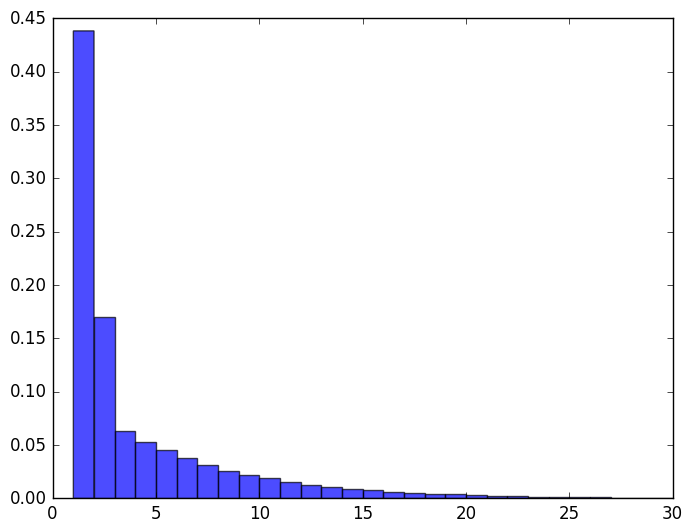

In [28]:
##Histogram for alpha=0.4
fig, ax = subplots()
ax[:set_xlim](0,30)
ax[:set_ylim](0.0,0.45)
#note the mix of all_t and all_t_bad
t40combi = vcat(all_t[1:40000,Int(40-round(100*lows))],all_t_bad[1:60000,Int(40-round(100*lows))])
ax[:hist](t40combi,bins=70,alpha=0.7,normed=true)
savefig("histogram40combi.png")
savefig("histogram40combi.pdf")